## 1. Prepare bam files

```shell
indir="name_sort_bam"
outdir="deduped_bam"
mkdir -p ${outdir}

rm -f name_sort_bam_to_deduped.sh
for file in `ls ${indir}`; do
    outfile=${file/hisat3n_dna.all_reads.name_sort.bam/bam}
    echo "czip name_sort_bam_to_deduped -I ${indir}/${file} -O ${outdir}/${outfile} --env yap" >> name_sort_bam_to_deduped.sh
done;
cat name_sort_bam_to_deduped.sh | parallel -j 96
```

## 2. Benchmark: `bam_to_cz` vs `bam_to_allc`

Convert every deduped, position-sorted BAM under to both formats and compare **runtime** and **peak memory** per cell:

- `bam_to_allc` (ALLCools) &rarr; `benchmark/allc/<cell>.allc.tsv.gz`
- `bam_to_cz`   (cytozip)  &rarr; `benchmark/cz/<cell>.cz`

Each conversion runs as an isolated subprocess wrapped in `/usr/bin/time -f '%e %M'`
so the reported wall-clock and peak RSS are measured independently. Per-cell metrics
are written to `bam_benchmark.tsv` / `bam_benchmark.txt` and rendered as a grouped
barplot (`bam_benchmark.pdf`, modelled on the one in `2.dnam.ipynb`).

> Set `N_CELLS` in the config cell to a small number (e.g. `24`) for a quick,
> readable per-cell barplot; set it to `None` to process **all** BAM files.


In [24]:
import os,sys
os.chdir(os.path.expanduser("~/Projects/test_cytozip"))

In [25]:
! pwd

/anvil/projects/x-mcb130189/Wubin/test_cytozip


In [26]:
import os, sys, time, subprocess, random
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed
import pandas as pd

# ---- paths --------------------------------------------------------------
BAM_DIR  = Path("~/Projects/test_cytozip/deduped_bam").expanduser()
BASE     = Path("~/Projects/test_cytozip/benchmark").expanduser()
ALLC_DIR = BASE / "allc"          # bam_to_allc outputs
CZ_DIR   = BASE / "cz"            # bam_to_cz  outputs
REF_FA   = Path("~/Ref/hg38/hg38_ucsc_with_chrL.fa").expanduser()
REF_CZ   = Path("~/Ref/hg38/hg38_with_chrL.allc.cz").expanduser()
REF_CHROM_SIZE = Path("~/Ref/hg38/hg38_ucsc_with_chrL.main.chrom.sizes").expanduser()
# czip build_ref -g ~/Ref/hg38/hg38_ucsc_with_chrL.fa -O ~/Ref/hg38/hg38_with_chrL.allc.cz -j 24 -s ~/Ref/hg38/hg38_ucsc_with_chrL.main.chrom.sizes

for d in (ALLC_DIR, CZ_DIR, BASE):
    d.mkdir(parents=True, exist_ok=True)

# 119 CPU 220G (a009)
# ---- run parameters -----------------------------------------------------
N_CELLS = 2000        # None = ALL bam files; an int randomly samples N cells
SEED    = 0        # RNG seed so the random cell subset is reproducible
JOBS    = 64        # cells processed in parallel (each = 1 allc + 1 cz, serial)

PY       = sys.executable
TIME_BIN = "/usr/bin/time"

# make `samtools` discoverable to child subprocesses (ALLCools shells out to it)
os.environ["PATH"] = str(Path(PY).parent) + os.pathsep + os.environ.get("PATH", "")

bams = sorted(BAM_DIR.glob("*.bam"))
bams = sorted(random.Random(SEED).sample(bams, min(N_CELLS, len(bams))))
bams = bams[:N_CELLS]

assert REF_FA.exists() and Path(str(REF_FA) + ".fai").exists(), "reference FASTA / .fai missing"
assert REF_CZ.exists(), f"reference .cz missing: {REF_CZ}"
print(f"{len(bams)} bam files to benchmark (JOBS={JOBS})")
print(f"  allc -> {ALLC_DIR}")
print(f"  cz   -> {CZ_DIR}")

2000 bam files to benchmark (JOBS=64)
  allc -> /home/x-wding2/Projects/test_cytozip/benchmark/allc
  cz   -> /home/x-wding2/Projects/test_cytozip/benchmark/cz


In [27]:
# from ALLCools._bam_to_allc import bam_to_allc
# %time bam_to_allc(bam_path="deduped_bam/UWA7648_CX1819_NAC_1_P10-1-K18-A10.bam", \
#                   reference_fasta=str(REF_FA), \
#                   output_path="UWA7648_CX1819_NAC_1_P10-1-K18-A10.allc.tsv.gz", \
#                   chroms=str(REF_CHROM_SIZE),\
#                   cpu=1,num_upstr_bases=0, num_downstr_bases=2, \
#                   min_mapq=10, min_base_quality=20)

# CPU times: user 2min 37s, sys: 13.6 s, total: 2min 50s
# Wall time: 3min 3s

In [28]:
# from cytozip.bam import bam_to_cz
# %time bam_to_cz(bam_path="deduped_bam/UWA7648_CX1819_NAC_1_P10-1-K18-A10.bam", \
#                   genome=str(REF_FA), chroms=str(REF_CHROM_SIZE),\
#                   output="UWA7648_CX1819_NAC_1_P10-1-K18-A10.cz", \
#                   reference=str(REF_CZ))

# CPU times: user 1min 18s, sys: 8.86 s, total: 1min 27s
# Wall time: 1min 29s                  

In [29]:
# ---- one isolated call per tool, timed with /usr/bin/time -----------------
_ALLC_CALL = (
    "from ALLCools._bam_to_allc import bam_to_allc; "
    "bam_to_allc(bam_path={bam!r}, reference_fasta={fa!r}, "
    "output_path={out!r}, chroms={chrom_size!r}, cpu=1, "
    "num_upstr_bases=0, num_downstr_bases=2, "
    "min_mapq=10, min_base_quality=20, compress_level=5)"
)
_CZ_CALL = (
    "from cytozip.bam import bam_to_cz; "
    "bam_to_cz(bam_path={bam!r}, genome={fa!r}, chroms={chrom_size!r}, "
    "output={out!r}, mode='mc_cov', count_fmt='B', reference={ref!r}, "
    "min_mapq=10, min_base_quality=20)"
)


def _time_child(cmd):
    """Run `cmd` under /usr/bin/time; return {ok, wall_s, rss_mb, stderr_tail}."""
    wrapped = [TIME_BIN, "-f", "__TIME__ %e %M", "--"] + list(cmd)
    res = subprocess.run(wrapped, capture_output=True, text=True)
    wall_s, rss_mb = float("nan"), float("nan")
    for line in res.stderr.splitlines()[::-1]:
        if line.startswith("__TIME__"):
            _, w, m = line.split()
            wall_s, rss_mb = float(w), float(m) / 1024.0   # %M is peak RSS in KB
            break
    return dict(ok=res.returncode == 0, wall_s=wall_s, rss_mb=rss_mb,
                stderr_tail="\n".join(res.stderr.splitlines()[-8:]))


def _count_reads(bam_path):
    """Number of alignment records in a BAM via `samtools view -c`."""
    try:
        res = subprocess.run(["samtools", "view", "-c", str(bam_path)],
                             capture_output=True, text=True)
        return int(res.stdout.strip()) if res.returncode == 0 else float("nan")
    except Exception:
        return float("nan")


# ---- incremental per-cell log (appended the moment each cell finishes) -----
import threading

LOG_TSV = BASE / "bam_benchmark.log.tsv"
_LOG_COLS = ["cell", "bam_size_mb", "n_reads",
             "allc_ok", "allc_wall_s", "allc_rss_mb", "allc_size_mb",
             "cz_ok", "cz_wall_s", "cz_rss_mb", "cz_size_mb"]
_LOG_LOCK = threading.Lock()


def _append_log(row):
    """Thread-safe append of one cell's metrics to LOG_TSV (header written once)."""
    line = "\t".join(str(row.get(c, "")) for c in _LOG_COLS)
    with _LOG_LOCK:
        new = (not LOG_TSV.exists()) or LOG_TSV.stat().st_size == 0
        with open(LOG_TSV, "a") as f:
            if new:
                f.write("\t".join(_LOG_COLS) + "\n")
            f.write(line + "\n")


def _load_log():
    """Load previously logged per-cell metrics as {cell: row_dict} (last wins)."""
    if (not LOG_TSV.exists()) or LOG_TSV.stat().st_size == 0:
        return {}
    prev = pd.read_csv(LOG_TSV, sep="\t")
    return {r["cell"]: r.to_dict() for _, r in prev.iterrows()}


def bench_one(bam_path, prev_log=None):
    """Convert one BAM to allc + cz, timing each conversion in isolation.

    If both output files already exist (non-empty), skip the (re)conversion
    and reuse the previously logged metrics (falling back to on-disk sizes).
    """
    prev_log = prev_log or {}
    bam = Path(bam_path)
    cid = bam.name[:-4]                       # strip trailing ".bam"
    allc_out = ALLC_DIR / f"{cid}.allc.tsv.gz"
    cz_out   = CZ_DIR / f"{cid}.cz"

    # ---- skip if both outputs already exist ----
    if (allc_out.exists() and allc_out.stat().st_size > 0
            and cz_out.exists() and cz_out.stat().st_size > 0):
        row = dict(prev_log.get(cid, {}))
        row.update(cell=cid, bam_size_mb=bam.stat().st_size / 1e6,
                   allc_size_mb=allc_out.stat().st_size / 1e6,
                   cz_size_mb=cz_out.stat().st_size / 1e6)
        # reuse a previously logged read count when available, else count now
        if ("n_reads" not in row) or pd.isna(row.get("n_reads", float("nan"))):
            row["n_reads"] = _count_reads(bam)
        row.setdefault("allc_ok", True)
        row.setdefault("cz_ok", True)
        for k in ("allc_wall_s", "allc_rss_mb", "cz_wall_s", "cz_rss_mb"):
            row.setdefault(k, float("nan"))
        row.setdefault("allc_err", "")
        row.setdefault("cz_err", "")
        row["skipped"] = True
        return row

    # ---- run both conversions (start clean so sizes/timings reflect this run) ----
    for p in (allc_out, Path(str(allc_out) + ".tbi"), cz_out):
        if p.exists():
            p.unlink()

    n_reads = _count_reads(bam)               # record read count for this cell
    r_a = _time_child([PY, "-c", _ALLC_CALL.format(
        bam=str(bam), fa=str(REF_FA), out=str(allc_out), chrom_size=str(REF_CHROM_SIZE))])
    r_c = _time_child([PY, "-c", _CZ_CALL.format(
        bam=str(bam), fa=str(REF_FA), out=str(cz_out), ref=str(REF_CZ), chrom_size=str(REF_CHROM_SIZE))])

    row = dict(
        cell=cid,
        bam_size_mb=bam.stat().st_size / 1e6,
        n_reads=n_reads,
        allc_ok=r_a["ok"], allc_wall_s=r_a["wall_s"], allc_rss_mb=r_a["rss_mb"],
        allc_size_mb=(allc_out.stat().st_size / 1e6) if allc_out.exists() else 0.0,
        cz_ok=r_c["ok"], cz_wall_s=r_c["wall_s"], cz_rss_mb=r_c["rss_mb"],
        cz_size_mb=(cz_out.stat().st_size / 1e6) if cz_out.exists() else 0.0,
        allc_err=r_a["stderr_tail"], cz_err=r_c["stderr_tail"],
        skipped=False,
    )
    _append_log(row)   # persist this cell's metrics immediately
    return row

In [30]:
def _report(i, r):
    if r.get("skipped"):
        tag = "SKIP"
    elif r["allc_ok"] and r["cz_ok"]:
        tag = "OK  "
    else:
        tag = "FAIL"
    if tag=='FAIL':
        print(f"[{i:>3}/{len(bams)}] {tag} {r['cell']:<40} "
            f"allc={r['allc_wall_s']:6.1f}s/{r['allc_rss_mb']:6.0f}MB  "
            f"cz={r['cz_wall_s']:6.1f}s/{r['cz_rss_mb']:6.0f}MB", flush=True)
        print("     allc_err:", r["allc_err"][-300:])
        print("     cz_err  :", r["cz_err"][-300:])

In [31]:
# ---- per-cell table -------------------------------------------------------
LOG_TSV = BASE / "bam_benchmark.log.tsv"
if LOG_TSV.exists() and LOG_TSV.stat().st_size > 0:
    # reuse the incrementally-written per-cell log instead of rebuilding from rows
    df = pd.read_csv(LOG_TSV, sep="\t").sort_values("cell").reset_index(drop=True)
    print("read", LOG_TSV)
else:
    # ---- run the benchmark --------------------------------------------------
    prev_log = _load_log()          # reuse metrics for already-converted cells
    t0 = time.perf_counter()
    rows = []
    if JOBS == 1:
        for i, b in enumerate(bams, 1):
            r = bench_one(str(b), prev_log)
            rows.append(r)
            _report(i, r)
    else:
        with ThreadPoolExecutor(max_workers=JOBS) as ex:
            futs = {ex.submit(bench_one, str(b), prev_log): b for b in bams}
            for i, fut in enumerate(as_completed(futs), 1):
                r = fut.result()
                rows.append(r)
                _report(i, r)
    print(f"\ntotal wall-clock: {time.perf_counter() - t0:.1f}s")
    df = pd.DataFrame(sorted(rows, key=lambda r: r["cell"]))
    df = df.drop(columns=["allc_err", "cz_err"], errors="ignore")

df["speedup"]    = df["allc_wall_s"] / df["cz_wall_s"]
df["mem_ratio"]  = df["cz_rss_mb"]   / df["allc_rss_mb"]
df["size_ratio"] = df["cz_size_mb"]  / df["allc_size_mb"]

tsv = BASE / "bam_benchmark.tsv"
df.to_csv(tsv, sep="\t", index=False, float_format="%.4f")
print("wrote", tsv)
df.round(2)

read /home/x-wding2/Projects/test_cytozip/benchmark/bam_benchmark.log.tsv
wrote /home/x-wding2/Projects/test_cytozip/benchmark/bam_benchmark.tsv


,cell,bam_size_mb,n_reads,allc_ok,allc_wall_s,allc_rss_mb,allc_size_mb,cz_ok,cz_wall_s,cz_rss_mb,cz_size_mb,speedup,mem_ratio,size_ratio
0,UWA7648_CX1819_NAC_1_P1-1-I3-A1,175.44,1790879,True,195.08,818.80,102.41,True,93.47,1171.36,23.42,2.09,1.43,0.23
1,UWA7648_CX1819_NAC_1_P1-1-I3-A10,174.83,1799068,True,187.59,818.76,100.89,True,92.72,1172.56,22.96,2.02,1.43,0.23
2,UWA7648_CX1819_NAC_1_P1-1-I3-A11,212.72,2179861,True,226.05,820.39,123.51,True,103.83,1172.82,27.43,2.18,1.43,0.22
3,UWA7648_CX1819_NAC_1_P1-1-I3-A12,200.91,2069300,True,228.31,820.22,116.86,True,99.90,1170.23,25.88,2.29,1.43,0.22
4,UWA7648_CX1819_NAC_1_P1-1-I3-A14,147.81,1518263,True,165.34,819.25,86.21,True,83.59,1169.82,20.28,1.98,1.43,0.24
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,UWA7648_CX1819_NAC_1_P9-1-M14-P21,186.10,1891577,True,198.13,818.49,109.12,True,95.70,1171.62,24.73,2.07,1.43,0.23
1996,UWA7648_CX1819_NAC_1_P9-1-M14-P22,170.61,1737293,True,175.84,818.51,99.03,True,88.85,1170.87,22.64,1.98,1.43,0.23
1997,UWA7648_CX1819_NAC_1_P9-1-M14-P3,209.62,2108920,True,211.04,818.32,123.38,True,102.81,1191.16,27.40,2.05,1.46,0.22
1998,UWA7648_CX1819_NAC_1_P9-1-M14-P5,172.25,1753059,True,178.78,818.68,98.67,True,90.24,1171.31,22.20,1.98,1.43,0.23


In [32]:
# ---- aggregate summary written to a text file -----------------------------
# keep only cells where BOTH allc and cz succeeded; if more than N_CELLS
# remain, randomly sample N_CELLS of them for the summary and all plots below.
df = df[df["allc_ok"] & df["cz_ok"]].reset_index(drop=True)
if N_CELLS is not None and len(df) > N_CELLS:
    df = df.sample(n=N_CELLS, random_state=SEED).sort_values("cell").reset_index(drop=True)
print(f"using {len(df)} cell(s) (allc_ok & cz_ok) for summary and plots")

tot_at, tot_ct = df["allc_wall_s"].sum(), df["cz_wall_s"].sum()
max_arss, max_crss = df["allc_rss_mb"].max(), df["cz_rss_mb"].max()
mean_arss, mean_crss = df["allc_rss_mb"].mean(), df["cz_rss_mb"].mean()
tot_as, tot_cs = df["allc_size_mb"].sum(), df["cz_size_mb"].sum()

txt = BASE / "bam_benchmark.txt"
txt.write_text(
    "cytozip bam_to_cz  vs  ALLCools bam_to_allc\n"
    "============================================\n"
    f"reference FASTA : {REF_FA}\n"
    f"reference .cz   : {REF_CZ}\n"
    f"cells           : {len(df)}\n"
    "\n"
    f"ALLCools : time={tot_at:9.1f} s   peak_rss(max)={max_arss:7.1f} MB   "
    f"mean_rss={mean_arss:7.1f} MB   size={tot_as:8.1f} MB\n"
    f"cytozip  : time={tot_ct:9.1f} s   peak_rss(max)={max_crss:7.1f} MB   "
    f"mean_rss={mean_crss:7.1f} MB   size={tot_cs:8.1f} MB\n"
    "\n"
    f"speedup   (allc / cz  time)      = {tot_at / max(tot_ct, 1e-9):5.2f}x\n"
    f"memory    (cz / allc  mean rss)  = {mean_crss / max(mean_arss, 1e-9) * 100:5.1f}%\n"
    f"compress  (cz / allc  size)      = {tot_cs / max(tot_as, 1e-9) * 100:5.1f}%\n"
)
print(txt.read_text())


using 2000 cell(s) (allc_ok & cz_ok) for summary and plots
cytozip bam_to_cz  vs  ALLCools bam_to_allc
reference FASTA : /home/x-wding2/Ref/hg38/hg38_ucsc_with_chrL.fa
reference .cz   : /home/x-wding2/Ref/hg38/hg38_with_chrL.allc.cz
cells           : 2000

ALLCools : time= 404399.5 s   peak_rss(max)=  825.5 MB   mean_rss=  818.3 MB   size=216815.3 MB
cytozip  : time= 192315.6 s   peak_rss(max)= 1360.5 MB   mean_rss= 1174.7 MB   size= 48255.4 MB

speedup   (allc / cz  time)      =  2.10x
memory    (cz / allc  mean rss)  = 143.6%
compress  (cz / allc  size)      =  22.3%



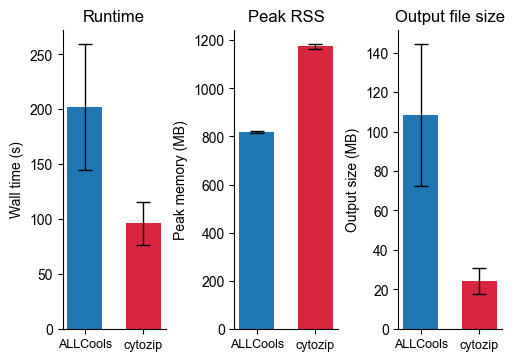

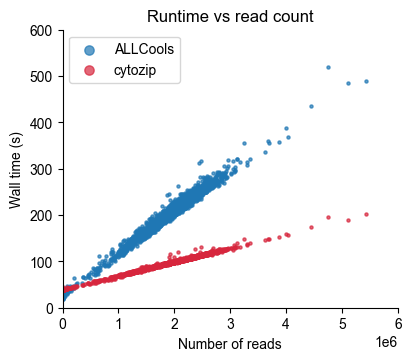

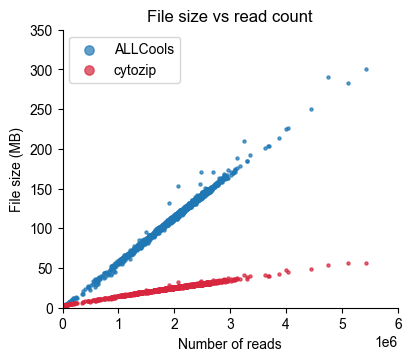

In [34]:
# ---- barplot: average runtime, peak memory & output size (mean +/- SD) -----
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['font.family'] = 'Arial'

d = df.copy()
n = len(d)
c_allc, c_cz = '#1f77b4', '#d7263d'
x = np.arange(2)                       # two tools per panel

metrics = [
    ('allc_wall_s', 'cz_wall_s',  'Wall time (s)',      'Runtime'),
    ('allc_rss_mb', 'cz_rss_mb',  'Peak memory (MB)',   'Peak RSS'),
    ('allc_size_mb', 'cz_size_mb', 'Output size (MB)',  'Output file size'),
]

fig, axes = plt.subplots(1, 3, figsize=(5, 3.5), constrained_layout=True)

for ax, (a_col, c_col, ylabel, title) in zip(axes, metrics):
    means = [d[a_col].mean(), d[c_col].mean()]
    sds   = [d[a_col].std(),  d[c_col].std()]
    ax.bar(x, means, yerr=sds, capsize=5, color=[c_allc, c_cz],
           width=0.6, error_kw=dict(ecolor='black', lw=1))
    ax.set_xticks(x)
    ax.set_xticklabels(['ALLCools', 'cytozip'], fontsize=9)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    for s in ('top', 'right'):
        ax.spines[s].set_visible(False)

tot_at, tot_ct = d['allc_wall_s'].sum(), d['cz_wall_s'].sum()
tot_as, tot_cs = d['allc_size_mb'].sum(), d['cz_size_mb'].sum()
# fig.suptitle(
#     f'BAM \u2192 ALLC vs BAM \u2192 CZ\n(n={n} cells, mean \u00b1 SD)   '
#     f'time: {tot_at:.0f} \u2192 {tot_ct:.0f} s '
#     f'({tot_at / max(tot_ct, 1e-9):.2f}\u00d7 faster)   '
#     f'mean RSS: {d["allc_rss_mb"].mean():.0f} \u2192 {d["cz_rss_mb"].mean():.0f} MB   '
#     f'size: {tot_as:.0f} \u2192 {tot_cs:.0f} MB '
#     f'({tot_cs / max(tot_as, 1e-9) * 100:.1f}%)',
#     fontsize=10,
# )

fig.savefig(BASE / 'bam_benchmark.pdf', bbox_inches='tight')
plt.show()

# ---- scatter plot: runtime vs number of reads (allc vs cz) ----------------
if 'n_reads' in d.columns:
    dl = d.dropna(subset=['n_reads'])
    fig2, ax2 = plt.subplots(figsize=(4, 3.5), constrained_layout=True)
    ax2.scatter(dl['n_reads'], dl['allc_wall_s'], s=5, alpha=0.7,
                color=c_allc, label='ALLCools',marker='o')
    ax2.scatter(dl['n_reads'], dl['cz_wall_s'], s=5, alpha=0.7,
                color=c_cz, label='cytozip',marker='o')
    ax2.set_xlabel('Number of reads')
    ax2.set_ylabel('Wall time (s)')
    ax2.set_xlim(0,6e6)
    ax2.set_ylim(0,600)
    ax2.set_title('Runtime vs read count')
    ax2.legend(frameon=True, fontsize=10,markerscale=3)
    for s in ('top', 'right'):
        ax2.spines[s].set_visible(False)
    fig2.savefig(BASE / 'bam_benchmark.runtime_vs_reads.pdf', bbox_inches='tight')
    plt.show()

# ---- scatter plot: output file size vs number of reads (allc vs cz) --------
if 'n_reads' in d.columns:
    dl = d.dropna(subset=['n_reads'])
    fig3, ax3 = plt.subplots(figsize=(4, 3.5), constrained_layout=True)
    ax3.scatter(dl['n_reads'], dl['allc_size_mb'], s=5, alpha=0.7,
                color=c_allc, label='ALLCools',marker='o')
    ax3.scatter(dl['n_reads'], dl['cz_size_mb'], s=5, alpha=0.7,
                color=c_cz, label='cytozip',marker='o')
    ax3.set_xlim(0,6e6)
    ax3.set_ylim(0, 350)
    ax3.set_xlabel('Number of reads')
    ax3.set_ylabel('File size (MB)')
    ax3.set_title('File size vs read count')
    ax3.legend(frameon=True, fontsize=10, markerscale=3)
    for s in ('top', 'right'):
        ax3.spines[s].set_visible(False)
    fig3.savefig(BASE / 'bam_benchmark.filesize_vs_reads.pdf', bbox_inches='tight')
    plt.show()

In [11]:
# runtime: 215 s for allc and 100s for .cz on average

## 3. Validate: do `allc` and `cz` store the same values?

Load the **entire** `allc` and `cz` files into memory and compare their
`(mc, cov)` values position-by-position. Any inconsistent record is printed.

Comparison rules (matching how each file stores data):

- **cz** is written in `mode='mc_cov'`, so it keeps only `[mc, cov]` aligned
  1:1 with the reference `.cz` positions. We recover coordinates from
  `REF_CZ` and **drop records with `cov == 0`** before comparing.
- **cz** stores counts as `uint8` (`count_fmt='B'`, max 255). Records whose
  **original allc `mc` or `cov` exceeds 255** are **excluded** from the
  comparison (they can't be matched exactly against the truncated cz value).
- ALLCools `bam_to_allc` has a known bug: the **last cytosine of every
  chromosome is dropped**. cz-only sites at each chromosome's last reference
  position are flagged separately (expected, not a real discrepancy).

We merge on `(chrom, pos)` and print every inconsistent record (value
mismatch, allc-only, or real cz-only).


In [12]:
# ---- helpers to load full allc / cz files for value comparison ------------
import numpy as np
from cytozip.cz import Reader

# cz stores mc/cov as uint8 ('B'), max 255. We keep the RAW allc values and
# later EXCLUDE any record whose original mc/cov > 255 (can't be compared
# exactly against the truncated cz). cz mode='mc_cov' stores every reference
# position; `Reader.to_df(reference=...)` recovers coordinates/strand/context
# and drops cov == 0 rows (drop_zero_cov=True by default).
COUNT_MAX = 255


def load_allc(allc_path):
    """Full ALLCools .allc.tsv.gz -> (chrom, pos, mc_allc, cov_allc), raw."""
    return pd.read_csv(
        allc_path, sep="\t", header=None, usecols=[0, 1, 4, 5],
        names=["chrom", "pos", "mc_allc", "cov_allc"],
        dtype={"chrom": str, "pos": np.int64,
               "mc_allc": np.int64, "cov_allc": np.int64},
    )


def load_cz(cz_path, reference=REF_CZ):
    """Full mode='mc_cov' cz -> (chrom, pos, strand, context, mc_cz, cov_cz).

    Uses ``Reader.to_df``: coordinates/strand/context come from the row-aligned
    reference and rows with cov == 0 are dropped (drop_zero_cov=True default).
    """
    r = Reader(str(cz_path))
    try:
        df = r.to_df(reference=str(reference))
    finally:
        r.close()
    return df.rename(columns={"mc": "mc_cz", "cov": "cov_cz"})


# ---- randomly pick N_COMPARE cell(s) that have BOTH an allc and a cz output
N_COMPARE = 100     # how many cells to compare (whole files loaded in memory)
_paired = [p.name[:-3] for p in sorted(CZ_DIR.glob("*.cz"))
           if (ALLC_DIR / f"{p.name[:-3]}.allc.tsv.gz").exists()]
CMP_CIDS = sorted(random.Random(SEED).sample(_paired, min(N_COMPARE, len(_paired))))
print(f"will compare {len(CMP_CIDS)} cell(s):")
# for cid in CMP_CIDS:
#     print("  ", cid)

will compare 100 cell(s):


In [13]:
# ---- compare full allc vs cz per cell (parallel across cells) -------------
from concurrent.futures import ProcessPoolExecutor, as_completed

# Each worker's load_cz -> to_df(reference=...) transiently decodes a whole
# chromosome of the reference (~1-2 GB) plus the allc table + merge. Running
# JOBS=64 of these at once exhausts RAM and the OS kills a worker, which the
# pool reports as `BrokenProcessPool`. Cap concurrency to keep peak memory
# bounded (tune CMP_JOBS up/down for your machine).
CMP_JOBS = min(12, JOBS, max(1, len(CMP_CIDS)))
print(CMP_JOBS)

def _compare_allc_cz(cid):
    """Compare one cell's allc vs cz; return (cid, n_bad, report_text)."""
    a = load_allc(ALLC_DIR / f"{cid}.allc.tsv.gz")     # whole allc (raw)
    c = load_cz(CZ_DIR / f"{cid}.cz")                  # whole cz (cov>0) via to_df

    m = a.merge(c[["chrom", "pos", "mc_cz", "cov_cz"]],
                on=["chrom", "pos"], how="outer", indicator=True)

    # EXCLUDE records affected by uint8 (255) truncation: any allc raw
    # mc/cov > 255 can't be compared exactly against the clipped cz value.
    truncated = ((m["mc_allc"] > COUNT_MAX) | (m["cov_allc"] > COUNT_MAX)).fillna(False)
    n_truncated = int(truncated.sum())
    m = m[~truncated].copy()

    both      = m["_merge"] == "both"
    cz_only   = m["_merge"] == "right_only"     # in cz (cov>0), not in allc
    allc_only = m["_merge"] == "left_only"      # in allc, cz cov==0 or absent

    # value mismatch on shared positions
    val_mis = both & ((m["mc_allc"] != m["mc_cz"]) | (m["cov_allc"] != m["cov_cz"]))

    # cz-only at each chrom's LAST covered position = known ALLCools
    # "drops the last cytosine of every chromosome" bug (not a cz error).
    last_pos = c.groupby("chrom")["pos"].max()
    m["last_pos"] = m["chrom"].map(last_pos)
    cz_only_lastC = cz_only & (m["pos"] == m["last_pos"])

    bad = m[val_mis | allc_only | (cz_only & ~cz_only_lastC)].copy()
    bad["issue"] = np.where(
        bad["_merge"] == "left_only", "allc_only",
        np.where(bad["_merge"] == "right_only", "cz_only", "value_mismatch"))

    lines = [
        f"\n===== {cid} =====",
        f"  allc records                 : {len(a):,}",
        f"  cz covered records (cov>0)   : {len(c):,}",
        f"  excluded (mc/cov > 255)      : {n_truncated:,}",
        f"  compared shared positions    : {int(both.sum()):,}",
        f"  value mismatches             : {int(val_mis.sum()):,}",
        f"  allc-only (cz cov==0/absent) : {int(allc_only.sum()):,}",
        f"  cz-only (real)               : {int((cz_only & ~cz_only_lastC).sum()):,}",
        f"  cz-only (ALLCools last-C bug): {int(cz_only_lastC.sum()):,}",
    ]
    if len(bad):
        cols = ["chrom", "pos", "mc_allc", "cov_allc", "mc_cz", "cov_cz", "issue"]
        lines.append(f"\n  --- {len(bad):,} INCONSISTENT records ---")
        with pd.option_context("display.max_rows", None, "display.width", 200):
            lines.append(bad[cols].sort_values(["chrom", "pos"]).to_string(index=False))
    return cid, len(bad), "\n".join(lines)


_reports, _nbad = {}, {}
with ProcessPoolExecutor(max_workers=CMP_JOBS) as ex:
    futs = {ex.submit(_compare_allc_cz, cid): cid for cid in CMP_CIDS}
    for i, fut in enumerate(as_completed(futs), 1):
        cid, n_bad, report = fut.result()
        _reports[cid] = report
        _nbad[cid] = n_bad
        print(f"{i}/{len(CMP_CIDS)} {cid}", end="\r")

# only print the inconsistent cells (stable cell order)
for cid in CMP_CIDS:
    if _nbad[cid] > 0:
        print(_reports[cid])

n_inconsistent = sum(1 for cid in CMP_CIDS if _nbad[cid] > 0)
n_identical = len(CMP_CIDS) - n_inconsistent
print(f"\n===== summary =====")
print(f"  cells compared : {len(CMP_CIDS)}")
print(f"  identical      : {n_identical}")
print(f"  inconsistent   : {n_inconsistent}")


12
100/100 UWA7648_CX1819_NAC_1_P9-1-M14-N15
===== summary =====
  cells compared : 100
  identical      : 100
  inconsistent   : 0


## 4. Benchmark: `allc2cz` (allc &rarr; cz) and compare with `bam_to_cz`

Convert every `benchmark/allc/<cell>.allc.tsv.gz` to a `.cz` file with
`cytozip.allc.allc2cz`, writing the results to `benchmark/allc2cz/<cell>.cz`
(created here). Each conversion runs as an isolated subprocess wrapped in
`/usr/bin/time -f '%e %M'` so **runtime** and **peak memory** are measured
independently per cell, and parallelised across cells.

Then:

- **Scatter plot**: X = number of covered cytosines per cell, Y = `allc2cz` runtime.
- **Consistency check**: compare `benchmark/cz/<cell>.cz` (from `bam_to_cz`)
  against `benchmark/allc2cz/<cell>.cz` (from `allc2cz`) position-by-position.
  Both are written in `mode='mc_cov'` with `uint8` (`'B'`) counts and are
  row-aligned to the same reference, so a direct array comparison is exact.


In [14]:
# ---- allc2cz benchmark: paths, call template, per-cell bench function ------
ALLC2CZ_DIR = BASE / "allc2cz"        # allc2cz outputs
ALLC2CZ_DIR.mkdir(parents=True, exist_ok=True)

# one isolated allc2cz call, timed with /usr/bin/time (reuses _time_child)
_ALLC2CZ_CALL = (
    "from cytozip.allc import allc2cz; "
    "allc2cz(input={allc!r}, output={out!r}, reference={ref!r})"
)

# incremental per-cell log for allc2cz (same pattern as the bam benchmark)
LOG_A2C_TSV = BASE / "allc2cz_benchmark.log.tsv"
_A2C_LOG_COLS = ["cell", "allc_size_mb", "a2c_ok", "a2c_wall_s",
                 "a2c_rss_mb", "a2c_cz_size_mb"]
_A2C_LOG_LOCK = threading.Lock()


def _append_a2c_log(row):
    line = "\t".join(str(row.get(c, "")) for c in _A2C_LOG_COLS)
    with _A2C_LOG_LOCK:
        new = (not LOG_A2C_TSV.exists()) or LOG_A2C_TSV.stat().st_size == 0
        with open(LOG_A2C_TSV, "a") as f:
            if new:
                f.write("\t".join(_A2C_LOG_COLS) + "\n")
            f.write(line + "\n")


def _load_a2c_log():
    if (not LOG_A2C_TSV.exists()) or LOG_A2C_TSV.stat().st_size == 0:
        return {}
    prev = pd.read_csv(LOG_A2C_TSV, sep="\t")
    return {r["cell"]: r.to_dict() for _, r in prev.iterrows()}


def bench_one_allc2cz(cid, prev_log=None):
    """Convert one allc.tsv.gz to cz with allc2cz, timing it in isolation.

    Skips (and reuses logged metrics) when the output .cz already exists.
    """
    prev_log = prev_log or {}
    allc_in = ALLC_DIR / f"{cid}.allc.tsv.gz"
    cz_out  = ALLC2CZ_DIR / f"{cid}.cz"

    if cz_out.exists() and cz_out.stat().st_size > 0:
        row = dict(prev_log.get(cid, {}))
        row.update(cell=cid, allc_size_mb=allc_in.stat().st_size / 1e6,
                   a2c_cz_size_mb=cz_out.stat().st_size / 1e6)
        row.setdefault("a2c_ok", True)
        for k in ("a2c_wall_s", "a2c_rss_mb"):
            row.setdefault(k, float("nan"))
        row.setdefault("a2c_err", "")
        row["skipped"] = True
        return row

    # allc2cz skips when output exists; start clean so timing reflects this run
    if cz_out.exists():
        cz_out.unlink()

    r = _time_child([PY, "-c", _ALLC2CZ_CALL.format(
        allc=str(allc_in), out=str(cz_out), ref=str(REF_CZ))])
    row = dict(
        cell=cid,
        allc_size_mb=allc_in.stat().st_size / 1e6,
        a2c_ok=r["ok"], a2c_wall_s=r["wall_s"], a2c_rss_mb=r["rss_mb"],
        a2c_cz_size_mb=(cz_out.stat().st_size / 1e6) if cz_out.exists() else 0.0,
        a2c_err=r["stderr_tail"], skipped=False,
    )
    _append_a2c_log(row)
    return row


# cells to convert = the allc files produced in section 2
a2c_cids = sorted(p.name[:-len(".allc.tsv.gz")]
                  for p in ALLC_DIR.glob("*.allc.tsv.gz"))
if N_CELLS is not None and len(a2c_cids) > N_CELLS:
    a2c_cids = sorted(random.Random(SEED).sample(a2c_cids, N_CELLS))
print(f"{len(a2c_cids)} allc file(s) to convert with allc2cz (JOBS={JOBS})")
print(f"  allc2cz -> {ALLC2CZ_DIR}")

2000 allc file(s) to convert with allc2cz (JOBS=64)
  allc2cz -> /home/x-wding2/Projects/test_cytozip/benchmark/allc2cz


In [15]:
def _report_a2c(i, r):
    if not r.get("a2c_ok", True):
        print(f"[{i:>3}/{len(a2c_cids)}] FAIL {r['cell']:<40} "
              f"a2c={r['a2c_wall_s']:6.1f}s/{r['a2c_rss_mb']:6.0f}MB", flush=True)
        print("     a2c_err:", r.get("a2c_err", "")[-300:])

In [16]:
# ---- table + scatter: covered cytosines vs allc2cz runtime -----------------
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from concurrent.futures import ProcessPoolExecutor
from cytozip.cz import Reader

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['font.family'] = 'Arial'

tsv = BASE / "allc2cz_benchmark.tsv"


def _count_cytosines(cz_path):
    """Number of covered cytosines (cov > 0) stored in a mode='mc_cov' cz."""
    cell = Reader(str(cz_path))
    n = 0
    for dim in cell.chunk_key2offset.keys():
        arr = cell.chunk2numpy(dim)
        n += int((arr["f1"] > 0).sum())      # f1 = cov
    cell.close()
    return n


if tsv.exists() and tsv.stat().st_size > 0:
    # reuse the previously computed table (includes n_cytosines)
    dfa = pd.read_csv(tsv, sep="\t")
    print("read", tsv)
else:
    # load the incremental per-cell log
    if LOG_A2C_TSV.exists() and LOG_A2C_TSV.stat().st_size > 0:
        dfa = pd.read_csv(LOG_A2C_TSV, sep="\t").drop_duplicates(
            "cell", keep="last").sort_values("cell").reset_index(drop=True)
    else:
        # ---- run the allc2cz benchmark --------------------------------------------
        prev_a2c = _load_a2c_log()      # reuse metrics for already-converted cells
        t0 = time.perf_counter()
        a2c_rows = []
        if JOBS == 1:
            for i, cid in enumerate(a2c_cids, 1):
                r = bench_one_allc2cz(cid, prev_a2c)
                a2c_rows.append(r)
                _report_a2c(i, r)
        else:
            with ProcessPoolExecutor(max_workers=JOBS) as ex:
                futs = {ex.submit(bench_one_allc2cz, cid, prev_a2c): cid for cid in a2c_cids}
                for i, fut in enumerate(as_completed(futs), 1):
                    r = fut.result()
                    a2c_rows.append(r)
                    _report_a2c(i, r)
        print(f"\ntotal wall-clock: {time.perf_counter() - t0:.1f}s")
        dfa = pd.DataFrame(a2c_rows).drop(columns=["a2c_err"], errors="ignore")

    dfa = dfa[dfa["a2c_ok"] == True].reset_index(drop=True)
    if N_CELLS is not None and len(dfa) > N_CELLS:
        dfa = dfa.sample(n=N_CELLS, random_state=SEED).sort_values("cell").reset_index(drop=True)

    # count covered cytosines per cell in parallel (order-preserving)
    cz_paths = [str(ALLC2CZ_DIR / f"{c}.cz") for c in dfa["cell"]]
    with ProcessPoolExecutor(max_workers=JOBS) as ex:
        dfa["n_cytosines"] = list(ex.map(_count_cytosines, cz_paths))

    dfa.to_csv(tsv, sep="\t", index=False, float_format="%.4f")
    print("wrote", tsv)

print(f"allc2cz: n={len(dfa)}  mean time={dfa['a2c_wall_s'].mean():.1f}s  "
      f"mean peak_rss={dfa['a2c_rss_mb'].mean():.0f}MB")


read /home/x-wding2/Projects/test_cytozip/benchmark/allc2cz_benchmark.tsv
allc2cz: n=200  mean time=52.5s  mean peak_rss=3709MB


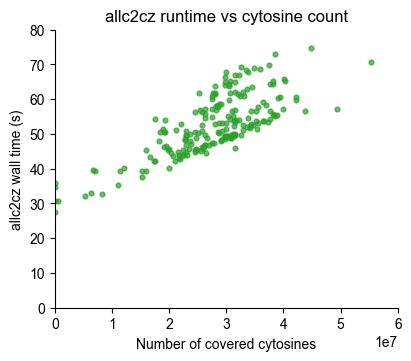

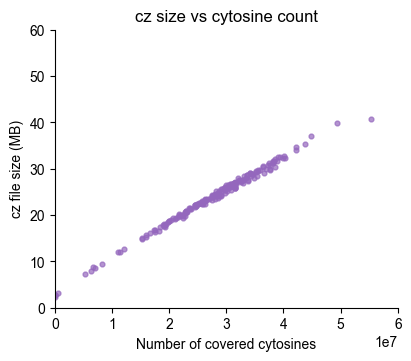

In [17]:
# scatter: X = number of covered cytosines, Y = allc2cz runtime
fig, ax = plt.subplots(figsize=(4, 3.5), constrained_layout=True)
ax.scatter(dfa["n_cytosines"], dfa["a2c_wall_s"], s=12, alpha=0.7, color='#2ca02c')
ax.set_xlabel('Number of covered cytosines')
ax.set_ylabel('allc2cz wall time (s)')
ax.set_title('allc2cz runtime vs cytosine count')
ax.set_xlim(0, 6e7)
ax.set_ylim(0, 80)
for s in ('top', 'right'):
    ax.spines[s].set_visible(False)
fig.savefig(BASE / 'allc2cz_benchmark.runtime_vs_cytosines.pdf', bbox_inches='tight')
plt.show()

# scatter: X = number of covered cytosines, Y = cz output file size
fig, ax = plt.subplots(figsize=(4, 3.5), constrained_layout=True)
ax.scatter(dfa["n_cytosines"], dfa["a2c_cz_size_mb"], s=12, alpha=0.7, color='#9467bd')
ax.set_xlabel('Number of covered cytosines')
ax.set_ylabel('cz file size (MB)')
ax.set_xlim(0, 6e7)
ax.set_ylim(0, 60)
ax.set_title('cz size vs cytosine count')
for s in ('top', 'right'):
    ax.spines[s].set_visible(False)
fig.savefig(BASE / 'allc2cz_benchmark.czsize_vs_cytosines.pdf', bbox_inches='tight')
plt.show()


### Compare `bam_to_cz` cz vs `allc2cz` cz

For every cell with outputs in **both** `benchmark/cz/` (from `bam_to_cz`) and
`benchmark/allc2cz/` (from `allc2cz`), compare the two `.cz` files
position-by-position. Both are `mode='mc_cov'`, `uint8` counts, and row-aligned
to the same reference `.cz`, so the arrays line up 1:1 per chromosome and can be
compared directly. Any `(mc, cov)` mismatch is a real difference between calling
methylation from the BAM directly vs going through the ALLCools `allc` file.


In [18]:
# ---- compare bam_to_cz cz vs allc2cz cz via Reader.to_df (parallel) --------
from cytozip.cz import Reader
from concurrent.futures import ProcessPoolExecutor, as_completed

N_COMPARE = 100
KEYS = ["chrom", "pos", "strand", "context"]


def compare_two_cz(cz_a, cz_b, reference=REF_CZ):
    """Compare two mode='mc_cov' cz files using ``Reader.to_df``.

    Both files are decoded against the same reference (coordinates + strand +
    context, cov>0 only) and joined on (chrom, pos, strand, context). Positions
    covered in only one file are treated as (mc, cov)=(0, 0) on the other side.
    Returns (n_positions_union, DataFrame_of_mismatches).
    """
    ra, rb = Reader(str(cz_a)), Reader(str(cz_b))
    try:
        da = ra.to_df(reference=str(reference)).rename(
            columns={"mc": "a_mc", "cov": "a_cov"})
        db = rb.to_df(reference=str(reference)).rename(
            columns={"mc": "b_mc", "cov": "b_cov"})
    finally:
        ra.close()
        rb.close()
    m = da.set_index(KEYS).join(db.set_index(KEYS), how="outer")
    val_cols = ["a_mc", "a_cov", "b_mc", "b_cov"]
    m[val_cols] = m[val_cols].fillna(0)
    bad = m[(m["a_mc"] != m["b_mc"]) | (m["a_cov"] != m["b_cov"])]
    return len(m), bad


def _compare_pair(cid):
    """Worker: compare one cell's two cz files; return (cid, n_pos, n_mis, head)."""
    n_pos, bad = compare_two_cz(CZ_DIR / f"{cid}.cz", ALLC2CZ_DIR / f"{cid}.cz")
    head = ""
    if len(bad):
        with pd.option_context("display.max_rows", 20, "display.width", 200):
            head = bad.reset_index().head(20).to_string(index=False)
    return cid, int(n_pos), int(len(bad)), head


# cells present in BOTH benchmark/cz and benchmark/allc2cz
_paired = sorted(p.name[:-3] for p in ALLC2CZ_DIR.glob("*.cz")
                 if (CZ_DIR / f"{p.name[:-3]}.cz").exists())
if N_COMPARE is not None and len(_paired) > N_COMPARE:
    _paired = sorted(random.Random(SEED).sample(_paired, N_COMPARE))
print(f"comparing {len(_paired)} cell(s): bam_to_cz vs allc2cz\n")

# Each worker decodes TWO whole-chromosome references via to_df (~2-4 GB peak),
# so keep concurrency low to avoid OOM -> BrokenProcessPool.
CMP_JOBS = min(8, JOBS, max(1, len(_paired)))

_res = {}
with ProcessPoolExecutor(max_workers=CMP_JOBS) as ex:
    futs = {ex.submit(_compare_pair, cid): cid for cid in _paired}
    for i, fut in enumerate(as_completed(futs), 1):
        cid, n_pos, n_mis, head = fut.result()
        _res[cid] = (n_pos, n_mis, head)
        print(f"{i}/{len(_paired)} {cid}", end="\r")

tot_pos, tot_mis, n_identical = 0, 0, 0
for cid in _paired:
    n_pos, n_mis, head = _res[cid]
    tot_pos += n_pos
    tot_mis += n_mis
    if n_mis == 0:
        n_identical += 1
        continue
    # only print inconsistent cells
    print(f"  {cid:<45} {n_pos:>12,} positions  {n_mis:,} mismatches")
    if head:
        print(head)

n_inconsistent = len(_paired) - n_identical
print(f"\n===== summary =====")
print(f"  cells compared            : {len(_paired)}")
print(f"  identical                 : {n_identical}")
print(f"  inconsistent              : {n_inconsistent}")
print(f"  total positions (union)   : {tot_pos:,}")
print(f"  total (mc,cov) mismatches : {tot_mis:,}"
      f"  ({tot_mis / max(tot_pos, 1) * 100:.4g}%)")

comparing 100 cell(s): bam_to_cz vs allc2cz

100/100 UWA7648_CX1819_NAC_1_P9-1-M14-N15
===== summary =====
  cells compared            : 100
  identical                 : 100
  inconsistent              : 0
  total positions (union)   : 2,793,100,038
  total (mc,cov) mismatches : 0  (0%)


In [22]:
from cytozip import Reader
reader1=Reader("benchmark/cz/UWA7648_CX1819_NAC_1_P13-1-I24-B15.cz")
df1=reader1.to_df(reference="~/Ref/hg38/hg38_with_chrL.allc.cz")
df1.rename(columns={'mc':'cz_mc','cov':'cz_cov'},inplace=True)
reader2=Reader("benchmark/allc2cz/UWA7648_CX1819_NAC_1_P13-1-I24-B15.cz")
df2=reader2.to_df(reference="~/Ref/hg38/hg38_with_chrL.allc.cz")
df2.rename(columns={'mc':'allc2cz_mc','cov':'allc2cz_cov'},inplace=True)
df=pd.concat([df1.set_index(['chrom','pos','strand','context']),df2.set_index(['chrom','pos','strand','context'])],axis=1)
df.loc[(df.cz_mc != df.allc2cz_mc) | (df.cz_cov != df.allc2cz_cov)]

,,,,cz_mc,cz_cov,allc2cz_mc,allc2cz_cov
chrom,pos,strand,context,,,,


In [23]:
df

cz_mc  cz_cov  allc2cz_mc  allc2cz_cov
chrom pos       strand context                                        
chr1  24456631  +      CAC          0       1           0            1
      24456633  +      CAT          0       1           0            1
      24456637  +      CCT          0       1           0            1
      24456638  +      CTG          0       1           0            1
      24456645  +      CCC          0       1           0            1
...                               ...     ...         ...          ...
chrX  136767326 +      CGC          0       1           0            1
      136767328 +      CCA          0       1           0            1
      136767329 +      CAC          0       1           0            1
      136767331 +      CCA          0       1           0            1
      136767332 +      CAG          0       1           0            1

[1195 rows x 4 columns]

In [20]:
# Query
! czip query -I ~/Projects/test_cytozip/benchmark/allc2cz/UWA7648_CX1819_NAC_1_P1-1-I3-J17.cz \
    -r ~/Ref/hg38/hg38_with_chrL.allc.cz -K chr9 -s 3000000 -e 3005000 | awk 'BEGIN{FS=OFS="\t"};{if(NR==1 || $6>0){print($0)}}'

chrom	pos	strand	context	mc	cov
chr9	3000596	-	CGG	1	1
chr9	3000603	-	CAT	0	1
chr9	3000604	-	CCA	0	1
chr9	3000608	-	CAG	0	1
chr9	3000612	-	CTG	0	1
chr9	3000613	-	CCT	0	1
chr9	3000620	-	CAG	0	1
chr9	3000622	-	CTC	0	1
chr9	3000631	-	CAG	0	1
chr9	3000632	-	CCA	0	1
chr9	3000633	-	CCC	0	1
chr9	3000636	-	CTG	0	1
chr9	3000642	-	CTG	0	1
chr9	3000646	-	CTT	0	1
chr9	3000648	-	CTC	0	1
chr9	3000649	-	CCT	0	1
chr9	3000651	-	CTC	0	1
chr9	3000652	-	CCT	0	1
chr9	3000655	-	CAG	0	1
chr9	3000660	-	CTG	0	1
chr9	3000667	-	CAA	0	1
chr9	3000670	-	CTG	0	1
chr9	3000672	-	CAC	0	1
chr9	3002113	-	CTT	0	1
chr9	3002116	-	CGA	1	1
chr9	3002127	-	CAA	0	1
chr9	3002131	-	CAG	0	1
chr9	3002137	-	CTA	0	1
chr9	3002145	-	CAA	0	1
chr9	3002147	-	CTC	0	1
chr9	3002151	-	CTG	0	1
chr9	3002152	-	CCT	0	1


In [21]:
# Query
! czip query -I ~/Projects/test_cytozip/benchmark/cz/UWA7648_CX1819_NAC_1_P1-1-I3-J17.cz \
    -r ~/Ref/hg38/hg38_with_chrL.allc.cz -K chr9 -s 3000000 -e 3005000 | awk 'BEGIN{FS=OFS="\t"};{if(NR==1 || $6>0){print($0)}}'

chrom	pos	strand	context	mc	cov
chr9	3000596	-	CGG	1	1
chr9	3000603	-	CAT	0	1
chr9	3000604	-	CCA	0	1
chr9	3000608	-	CAG	0	1
chr9	3000612	-	CTG	0	1
chr9	3000613	-	CCT	0	1
chr9	3000620	-	CAG	0	1
chr9	3000622	-	CTC	0	1
chr9	3000631	-	CAG	0	1
chr9	3000632	-	CCA	0	1
chr9	3000633	-	CCC	0	1
chr9	3000636	-	CTG	0	1
chr9	3000642	-	CTG	0	1
chr9	3000646	-	CTT	0	1
chr9	3000648	-	CTC	0	1
chr9	3000649	-	CCT	0	1
chr9	3000651	-	CTC	0	1
chr9	3000652	-	CCT	0	1
chr9	3000655	-	CAG	0	1
chr9	3000660	-	CTG	0	1
chr9	3000667	-	CAA	0	1
chr9	3000670	-	CTG	0	1
chr9	3000672	-	CAC	0	1
chr9	3002113	-	CTT	0	1
chr9	3002116	-	CGA	1	1
chr9	3002127	-	CAA	0	1
chr9	3002131	-	CAG	0	1
chr9	3002137	-	CTA	0	1
chr9	3002145	-	CAA	0	1
chr9	3002147	-	CTC	0	1
chr9	3002151	-	CTG	0	1
chr9	3002152	-	CCT	0	1
